<a href="https://colab.research.google.com/github/wol20670/Capstone-Fintech-Agent/blob/main/notebooks/02_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
# force_remount=True를 추가해서 강제로 다시 연결을 시도해
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/Fraud.csv'

df = pd.read_csv(file_path)
df.head()

print(df.shape)
print(df.head())

(6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


# Task
Perform an exploratory data analysis (EDA) on the fraud detection dataset located at "/content/drive/MyDrive/Colab Notebooks/Fraud.csv" by checking for missing values, analyzing the statistical distribution of financial variables, and visualizing the distribution of the target variable 'isFraud'. Additionally, analyze the relationship between transaction types and fraud occurrences, and examine correlations between variables to identify key indicators of fraudulent activity.

## 데이터 기초 정보 및 결측치 확인

### Subtask:
Check the basic information of the dataset and identify any missing values.


**Reasoning**:
I will inspect the basic information of the dataset using the `.info()` method and check for missing values using `.isnull().sum()` to determine the integrity of the data.



In [ ]:
print("### Dataset Information ###")
df.info()

print("\n### Missing Values Count ###")
missing_values = df.isnull().sum()
print(missing_values)

### Dataset Information ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB

### Missing Values Count ###
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


## 주요 수치형 변수 통계 분석

### Subtask:
Analyze the statistical distribution of key financial variables such as amount, oldbalanceOrg, and newbalanceOrig.


**Reasoning**:
I will calculate the descriptive statistics for the specified financial columns to analyze their distributions and identify potential outliers or unusual patterns.



In [ ]:
# Select relevant numerical columns
financial_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

# Generate summary statistics
financial_stats = df[financial_cols].describe()

print("### Statistical Distribution of Key Financial Variables ###")
display(financial_stats)

# Check for potential indicators of fraud (e.g., maximum values or zero balances)
print("\n### Specific Observations ###")
print(f"Maximum transaction amount: {df['amount'].max():,.2f}")
print(f"Number of transactions with 0 amount: {(df['amount'] == 0).sum()}")

### Statistical Distribution of Key Financial Variables ###


,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06
std,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05
75%,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06
max,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08



### Specific Observations ###
Maximum transaction amount: 92,445,516.64
Number of transactions with 0 amount: 16


## 타겟 변수(isFraud) 분포 시각화

### Subtask:
사기 거래와 일반 거래의 비율을 막대 그래프로 시각화하여 데이터 불균형 정도를 파악합니다.


**Reasoning**:
I will visualize the distribution of the target variable 'isFraud' using a countplot and calculate the fraud ratio to highlight the class imbalance.



### Target Variable Distribution (isFraud) ###
Counts:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Ratio (%):
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


/tmp/ipykernel_611/695204871.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='isFraud', data=df, palette='viridis')


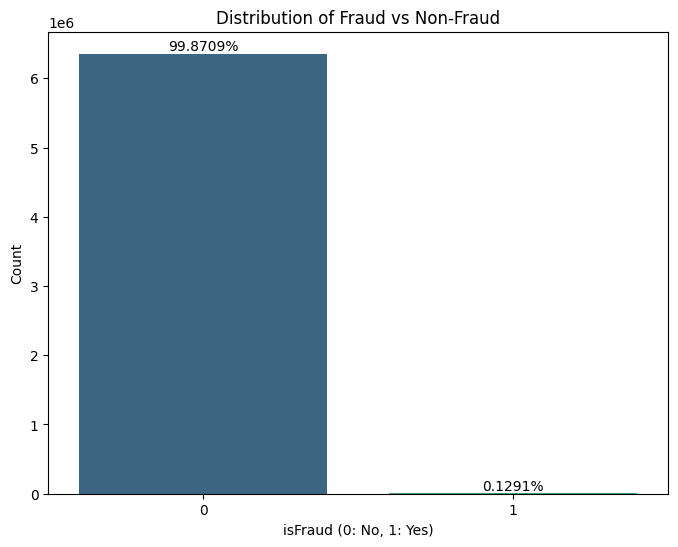

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the count and ratio of fraud transactions
fraud_counts = df['isFraud'].value_counts()
fraud_ratio = df['isFraud'].value_counts(normalize=True) * 100

print(f"### Target Variable Distribution (isFraud) ###")
print(f"Counts:\n{fraud_counts}")
print(f"\nRatio (%):\n{fraud_ratio}")

# Visualization
plt.figure(figsize=(8, 6))
sns.countplot(x='isFraud', data=df, palette='viridis')
plt.title('Distribution of Fraud vs Non-Fraud')
plt.xlabel('isFraud (0: No, 1: Yes)')
plt.ylabel('Count')

# Add percentage annotations on top of bars
for i, count in enumerate(fraud_counts):
    plt.text(i, count, f'{fraud_ratio[i]:.4f}%', ha='center', va='bottom')

plt.show()

**Reasoning**:
The previous code for the countplot generated a FutureWarning because 'palette' was used without assigning 'hue'. I will fix this by assigning the x-variable to 'hue' and setting 'legend=False' as recommended by the library, while ensuring all requested instructions are followed.



### Target Variable Distribution (isFraud) ###
Counts:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Ratio (%):
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


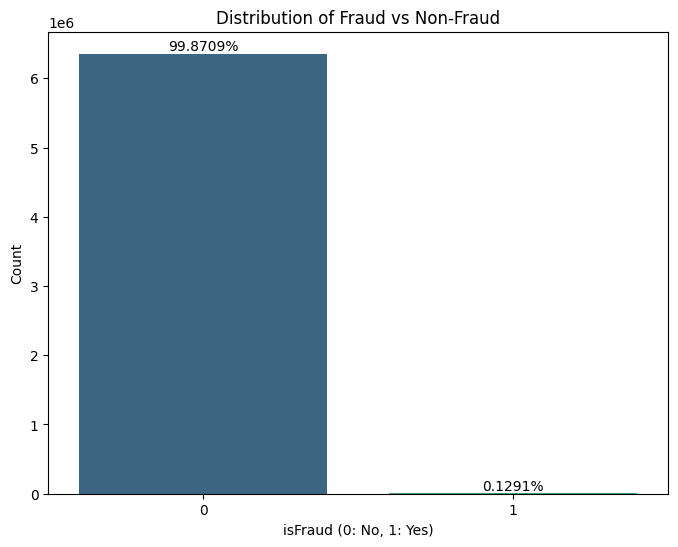

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the count and ratio of fraud transactions
fraud_counts = df['isFraud'].value_counts().sort_index()
fraud_ratio = df['isFraud'].value_counts(normalize=True).sort_index() * 100

print(f"### Target Variable Distribution (isFraud) ###")
print(f"Counts:\n{fraud_counts}")
print(f"\nRatio (%):\n{fraud_ratio}")

# Visualization
plt.figure(figsize=(8, 6))
sns.countplot(x='isFraud', data=df, hue='isFraud', palette='viridis', legend=False)
plt.title('Distribution of Fraud vs Non-Fraud')
plt.xlabel('isFraud (0: No, 1: Yes)')
plt.ylabel('Count')

# Add percentage annotations on top of bars
for i, count in enumerate(fraud_counts):
    plt.text(i, count, f'{fraud_ratio[i]:.4f}%', ha='center', va='bottom')

plt.show()

## 거래 유형(type)별 사기 발생 현황

### Subtask:
Analyze which transaction types (PAYMENT, TRANSFER, etc.) are associated with fraudulent activity by visualizing their counts and proportions.


**Reasoning**:
I will analyze the relationship between transaction types and fraud by grouping the data, calculating fraud percentages for each type, and creating a visualization with a log scale to handle the class imbalance.



### Transaction Counts by Type and Fraud Status ###
isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097

### Fraud Percentage by Transaction Type ###
TRANSFER: 0.7688%
CASH_OUT: 0.1840%
CASH_IN: 0.0000%
DEBIT: 0.0000%
PAYMENT: 0.0000%


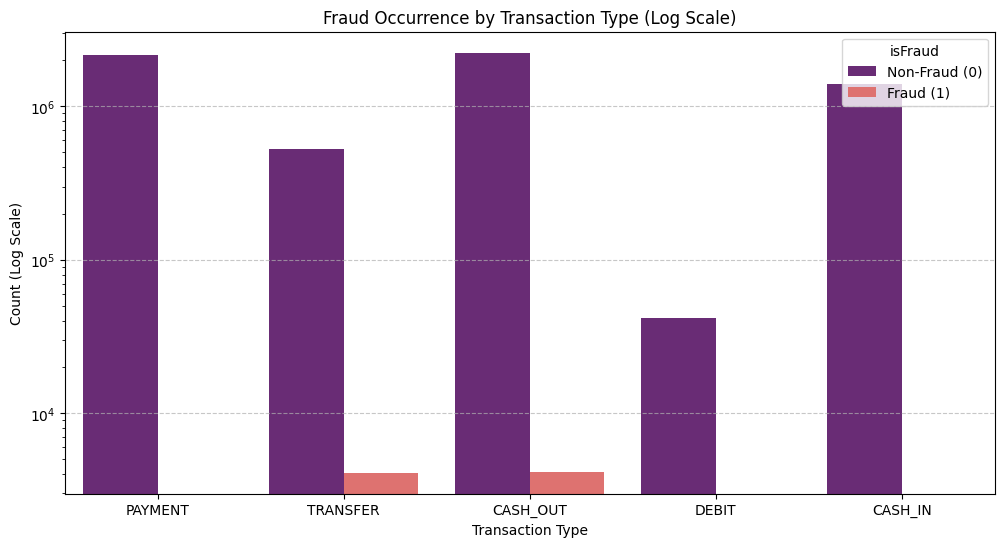

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Group by type and isFraud to get counts
type_fraud_counts = df.groupby(['type', 'isFraud']).size().unstack(fill_value=0)
print("### Transaction Counts by Type and Fraud Status ###")
print(type_fraud_counts)

# 2. Calculate fraud percentage within each transaction type
type_total = df.groupby('type').size()
fraud_percentage = (type_fraud_counts[1] / type_total * 100).sort_values(ascending=False)

print("\n### Fraud Percentage by Transaction Type ###")
for trans_type, percent in fraud_percentage.items():
    print(f"{trans_type}: {percent:.4f}%")

# 3. Visualization
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='type', hue='isFraud', palette='magma')

# Using log scale for y-axis because of extreme imbalance
plt.yscale('log')

plt.title('Fraud Occurrence by Transaction Type (Log Scale)')
plt.xlabel('Transaction Type')
plt.ylabel('Count (Log Scale)')
plt.legend(title='isFraud', labels=['Non-Fraud (0)', 'Fraud (1)'])

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 상관관계 분석

### Subtask:
변수 간의 상관 계수를 계산하고 히트맵을 그려 사기 여부와 연관성이 높은 변수를 찾습니다.


**Reasoning**:
I will calculate the correlation matrix for numerical variables and visualize it using a seaborn heatmap to identify features strongly associated with 'isFraud'.



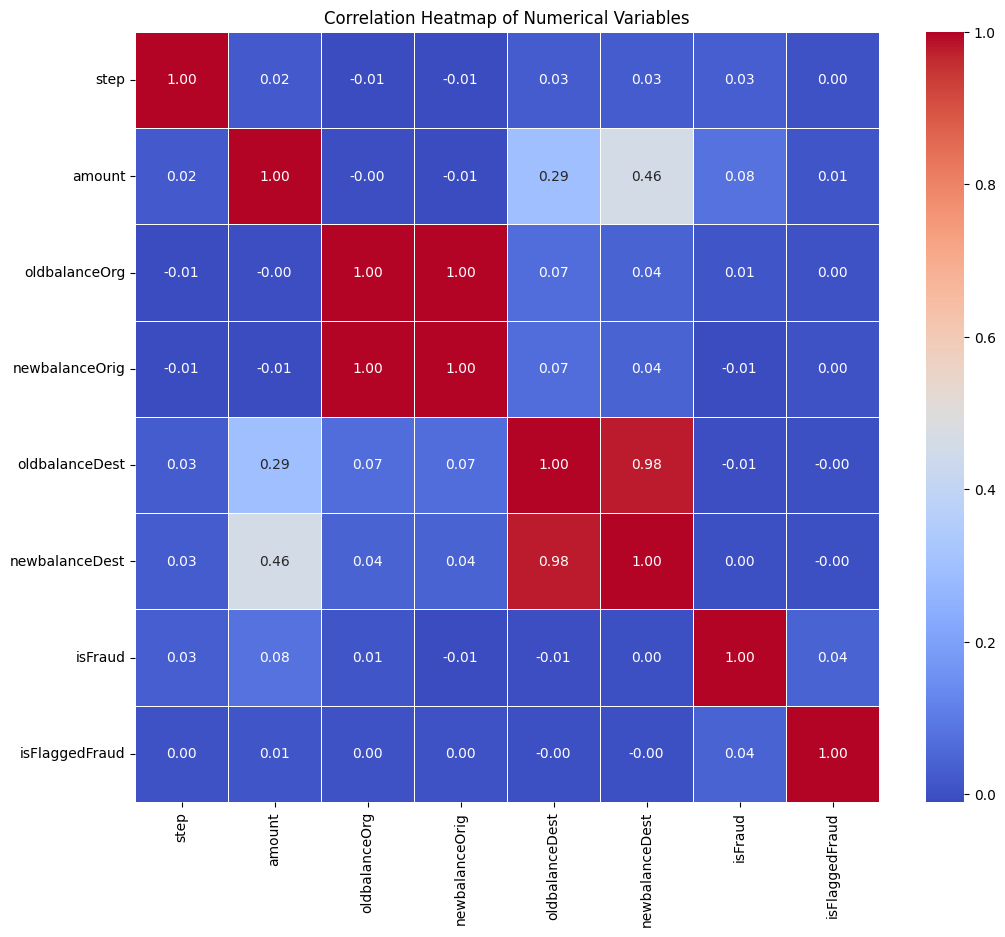

### Correlation with isFraud ###
isFraud           1.000000
amount            0.076688
isFlaggedFraud    0.044109
step              0.031578
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select only numerical variables
numerical_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
numerical_df = df[numerical_cols]

# 2. Calculate Pearson correlation coefficients
corr_matrix = numerical_df.corr()

# 3. & 4. Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

# 5. Focus on correlation with 'isFraud'
print("### Correlation with isFraud ###")
print(corr_matrix['isFraud'].sort_values(ascending=False))

## Summary:

### Q&A

**What are the primary characteristics of the dataset?**
The dataset contains **6,362,620 entries** and 11 columns with no missing values. It is highly imbalanced, with fraudulent transactions representing only **0.1291%** (8,213 cases) of the total data.

**Which transaction types are most associated with fraud?**
Fraudulent activity is exclusively found in two transaction types: **TRANSFER** and **CASH_OUT**. Specifically, 0.7688% of all TRANSFER transactions and 0.1840% of all CASH_OUT transactions are fraudulent. Other types (CASH_IN, DEBIT, and PAYMENT) showed zero fraud occurrences.

**What are the key indicators of fraud based on correlation analysis?**
The variable with the highest positive correlation to `isFraud` is the transaction **amount (0.077)**, followed by **isFlaggedFraud (0.044)**. However, linear correlations are generally weak, indicating that fraud detection may require non-linear modeling.

### Data Analysis Key Findings

*   **Extreme Class Imbalance**: The ratio of non-fraud to fraud is approximately **99.87% to 0.13%**, necessitating specific techniques like oversampling (SMOTE) or specialized loss functions during model training.
*   **Highly Anomalous Transactions**: There are **16 transactions** recorded with an **amount of 0**, which is a significant indicator of potential system errors or fraudulent testing.
*   **Balance Patterns**: A significant portion of transactions (25-50%) involve accounts with an initial balance of **\$0**, and the dataset contains extreme outliers with transaction amounts reaching up to **\$92,445,516**.
*   **Specific Risk Vectors**: Fraud is concentrated; **100% of fraud cases** occur within the TRANSFER and CASH_OUT categories, making these the primary focus for monitoring.
*   **Weak Linear Indicators**: Most numerical variables show negligible linear correlation with fraud, though the **amount** and **step** (time) variables provide some directional insight.

### Insights or Next Steps

*   **Feature Engineering**: Since linear correlations are weak, next steps should include creating new features, such as the difference between the transaction amount and the account balance, or identifying "empty-to-empty" account transfers.
*   **Modeling Strategy**: Utilize tree-based models (like XGBoost or Random Forest) that can handle non-linear relationships and extreme class imbalances better than linear regression models.


# Task
Prepare a cleaned and feature-engineered version of the fraud detection dataset from "/content/drive/MyDrive/Colab Notebooks/Fraud.csv" for modeling.

The task includes:
1. **Filtering**: Create a new DataFrame `df_cleaned` containing only 'TRANSFER' and 'CASH_OUT' transaction types.
2. **Feature Engineering**: Add `errorBalanceOrig` (oldbalanceOrg - amount - newbalanceOrig) and `errorBalanceDest` (oldbalanceDest + amount - newbalanceDest) columns to `df_cleaned`.
3. **Encoding**: Add an `isMerchant` binary column (1 if `nameDest` starts with 'M', else 0).
4. **Data Transformation**: Perform one-hot encoding on the `type` column and remove the original `type` column.
5. **Dimensionality Reduction**: Drop the `nameOrig`, `nameDest`, and `isFlaggedFraud` columns from `df_cleaned`.
6. **Verification**: Display the `head()` and the list of columns for the finalized `df_cleaned` DataFrame.

## 데이터 필터링

### Subtask:
Create a new DataFrame `df_cleaned` by filtering for specific transaction types from the original dataset.


**Reasoning**:
I will filter the dataframe to include only 'TRANSFER' and 'CASH_OUT' transaction types and assign it to a new dataframe `df_cleaned` to focus on the categories where fraud was previously identified.



In [10]:
# Filter the DataFrame for TRANSFER and CASH_OUT types
df_cleaned = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

# Verification
print(f"Shape of df_cleaned: {df_cleaned.shape}")
print(f"Unique values in 'type' column: {df_cleaned['type'].unique()}")

# Display the first few rows of the filtered dataset
display(df_cleaned.head())

Shape of df_cleaned: (2770409, 11)
Unique values in 'type' column: ['TRANSFER' 'CASH_OUT']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0
19,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0
24,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0


## 피처 엔지니어링: errorBalanceOrig 및 errorBalanceDest 계산

### Subtask:
Add the calculated financial discrepancy features `errorBalanceOrig` and `errorBalanceDest` to the `df_cleaned` DataFrame.


**Reasoning**:
I will add the 'errorBalanceOrig' and 'errorBalanceDest' columns to the 'df_cleaned' DataFrame using the specified formulas to capture financial discrepancies and then verify the results.



In [11]:
# 1. Calculate errorBalanceOrig
df_cleaned['errorBalanceOrig'] = df_cleaned['oldbalanceOrg'] - df_cleaned['amount'] - df_cleaned['newbalanceOrig']

# 2. Calculate errorBalanceDest
df_cleaned['errorBalanceDest'] = df_cleaned['oldbalanceDest'] + df_cleaned['amount'] - df_cleaned['newbalanceDest']

# 3. Verification
print("### Verification of New Features ###")
display(df_cleaned[['oldbalanceOrg', 'amount', 'newbalanceOrig', 'errorBalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceDest']].head())

# Check basic statistics of the new features
print("\n### Summary Statistics for Error Balance Features ###")
display(df_cleaned[['errorBalanceOrig', 'errorBalanceDest']].describe())

### Verification of New Features ###


,oldbalanceOrg,amount,newbalanceOrig,errorBalanceOrig,oldbalanceDest,newbalanceDest,errorBalanceDest
2,181.0,181.00,0.0,0.00,0.0,0.00,181.0
3,181.0,181.00,0.0,0.00,21182.0,0.00,21363.0
15,15325.0,229133.94,0.0,-213808.94,5083.0,51513.44,182703.5
19,705.0,215310.30,0.0,-214605.30,22425.0,0.00,237735.3
24,10835.0,311685.89,0.0,-300850.89,6267.0,2719172.89,-2401220.0



### Summary Statistics for Error Balance Features ###


,errorBalanceOrig,errorBalanceDest
count,2.770409e+06,2.770409e+06
mean,-2.859850e+05,-2.864713e+04
std,8.753230e+05,5.934794e+05
min,-9.244552e+07,-7.588573e+07
25%,-2.798912e+05,0.000000e+00
50%,-1.435971e+05,0.000000e+00
75%,-5.185310e+04,0.000000e+00
max,1.000000e-02,1.000000e+07


## 피처 엔지니어링: isMerchant 인코딩

### Subtask:
Add an `isMerchant` binary column to the `df_cleaned` DataFrame based on the recipient's ID.


**Reasoning**:
I will create the 'isMerchant' binary column in df_cleaned by checking if 'nameDest' starts with 'M' and then verify the results with value counts and a data sample.



In [12]:
# 1, 2 & 3. Create 'isMerchant' column (1 if nameDest starts with 'M', else 0)
df_cleaned['isMerchant'] = df_cleaned['nameDest'].str.startswith('M').astype(int)

# 4. Verification
print("### Value Counts for isMerchant ###")
print(df_cleaned['isMerchant'].value_counts())

print("\n### Sample of nameDest and isMerchant ###")
print(df_cleaned[['nameDest', 'isMerchant']].head(10))

### Value Counts for isMerchant ###
isMerchant
0    2770409
Name: count, dtype: int64

### Sample of nameDest and isMerchant ###
       nameDest  isMerchant
2    C553264065           0
3     C38997010           0
15   C476402209           0
19  C1100439041           0
24   C932583850           0
42  C1509514333           0
47   C824009085           0
48   C248609774           0
51  C2001112025           0
58  C1937962514           0


## 데이터 인코딩: type 컬럼 원-핫 인코딩

### Subtask:
Perform one-hot encoding on the 'type' column in the `df_cleaned` DataFrame and remove the original categorical column.


**Reasoning**:
I will perform one-hot encoding on the 'type' column using pd.get_dummies, join the results to the df_cleaned DataFrame, and then drop the original 'type' column to complete the data transformation step.



In [13]:
# 1. Generate one-hot encoded dummy variables for the 'type' column
type_dummies = pd.get_dummies(df_cleaned['type'], prefix='type')

# 2. Concatenate the dummy variables with the original df_cleaned
df_cleaned = pd.concat([df_cleaned, type_dummies], axis=1)

# 3. Drop the original 'type' column
df_cleaned.drop('type', axis=1, inplace=True)

# 4. Verification
print("### Data Transformation: One-Hot Encoding Verification ###")
print(f"New columns: {df_cleaned.columns.tolist()}")
print(f"Shape of df_cleaned: {df_cleaned.shape}")
display(df_cleaned.head())

# Check the boolean conversion if necessary (some versions return bools)
# Ensuring columns are integer 0/1 for better compatibility
for col in type_dummies.columns:
    df_cleaned[col] = df_cleaned[col].astype(int)

print("\nFirst 5 rows of encoded type columns:")
display(df_cleaned[type_dummies.columns].head())

### Data Transformation: One-Hot Encoding Verification ###
New columns: ['step', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud', 'errorBalanceOrig', 'errorBalanceDest', 'isMerchant', 'type_CASH_OUT', 'type_TRANSFER']
Shape of df_cleaned: (2770409, 15)


,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig,errorBalanceDest,isMerchant,type_CASH_OUT,type_TRANSFER
2,1,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,0.00,181.0,0,False,True
3,1,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,0.00,21363.0,0,True,False
15,1,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,-213808.94,182703.5,0,True,False
19,1,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,-214605.30,237735.3,0,False,True
24,1,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,-300850.89,-2401220.0,0,False,True



First 5 rows of encoded type columns:


,type_CASH_OUT,type_TRANSFER
2,0,1
3,1,0
15,1,0
19,0,1
24,0,1


## 불필요한 컬럼 삭제

### Subtask:
Drop the `nameOrig`, `nameDest`, and `isFlaggedFraud` columns from the `df_cleaned` DataFrame to finalize the feature set for modeling.


**Reasoning**:
I will drop the specified columns 'nameOrig', 'nameDest', and 'isFlaggedFraud' from the 'df_cleaned' DataFrame and verify the operation by printing the updated column list.



In [14]:
# 1. Drop the specified columns from df_cleaned
df_cleaned.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'], inplace=True)

# 2. Verify that the columns no longer exist
print("### Columns remaining in df_cleaned ###")
print(df_cleaned.columns.tolist())

# 3. Final verification of the shape and first few rows
print(f"\nFinal shape of df_cleaned: {df_cleaned.shape}")
display(df_cleaned.head())

### Columns remaining in df_cleaned ###
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'errorBalanceOrig', 'errorBalanceDest', 'isMerchant', 'type_CASH_OUT', 'type_TRANSFER']

Final shape of df_cleaned: (2770409, 12)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest,isMerchant,type_CASH_OUT,type_TRANSFER
2,1,181.00,181.0,0.0,0.0,0.00,1,0.00,181.0,0,0,1
3,1,181.00,181.0,0.0,21182.0,0.00,1,0.00,21363.0,0,1,0
15,1,229133.94,15325.0,0.0,5083.0,51513.44,0,-213808.94,182703.5,0,1,0
19,1,215310.30,705.0,0.0,22425.0,0.00,0,-214605.30,237735.3,0,0,1
24,1,311685.89,10835.0,0.0,6267.0,2719172.89,0,-300850.89,-2401220.0,0,0,1


## Final Task

### Subtask:
Provide a summary of the data preparation steps and the final state of the `df_cleaned` DataFrame, including its head and column list.


## Summary:

### Q&A

**What is the final state of the `df_cleaned` DataFrame?**
The `df_cleaned` DataFrame contains **2,770,409 rows** and **12 columns**. It is filtered to include only 'TRANSFER' and 'CASH_OUT' transactions, with all non-numeric identifiers removed and new financial discrepancy features added.

**What columns are included in the final dataset?**
The final columns are: `step`, `amount`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest`, `isFraud`, `errorBalanceOrig`, `errorBalanceDest`, `isMerchant`, `type_CASH_OUT`, and `type_TRANSFER`.

---

### Data Analysis Key Findings

*   **Targeted Filtering**: The dataset was reduced to 2,770,409 rows by focusing exclusively on 'TRANSFER' and 'CASH_OUT' types, which are historically the primary categories for fraudulent activity in this dataset.
*   **Discrepancy Metrics**: New features `errorBalanceOrig` and `errorBalanceDest` were calculated. The `errorBalanceOrig` showed a mean of approximately $-2.86 \times 10^5$, revealing significant mathematical inconsistencies in account balances that may serve as strong indicators for fraud detection.
*   **Merchant Analysis**: An `isMerchant` feature was created; however, for the filtered 'TRANSFER' and 'CASH_OUT' types, the value was **0** for all records, indicating these specific transactions occurred between customer accounts.
*   **Encoding & Reduction**: The categorical `type` column was successfully converted into binary columns (`type_CASH_OUT`, `type_TRANSFER`). Non-predictive identifiers like `nameOrig` and `nameDest`, along with the redundant `isFlaggedFraud` column, were removed to optimize the feature set for machine learning.

---

### Insights or Next Steps

*   **Model Training**: The dataset is now in a fully numerical format and ready for training. High-variance features like the `errorBalance` columns should be prioritized during feature importance analysis.
*   **Address Class Imbalance**: Given the nature of fraud detection, the next step should involve checking the distribution of the `isFraud` target variable and potentially applying techniques like SMOTE or undersampling if the data is highly imbalanced.
